Classificação de Imagens com MobileNetV3 Small (timm)
Este notebook utiliza o modelo timm/mobilenetv3_small_100.lamb_in1k para classificar as imagens contidas na pasta imagens.

In [2]:
import torch
import timm
from PIL import Image
import os
from urllib.request import urlopen
import matplotlib.pyplot as plt

print(f"PyTorch version: {torch.__version__}")
print(f"Timm version: {timm.__version__}")

PyTorch version: 2.10.0+cpu
Timm version: 1.0.25


1. Carregando o Modelo e as Labels
Vamos carregar o modelo pré-treinado e as categorias do ImageNet.

In [3]:
# O nome do modelo conforme solicitado
model_name = 'mobilenetv3_small_100.lamb_in1k'

try:
    # Tenta carregar diretamente pelo nome do timm
    model = timm.create_model(model_name, pretrained=True)
except Exception as e:
    print(f"Erro ao carregar modelo normal, tentando via HF Hub: {e}")
    # Tenta carregar via Hugging Face Hub se falhar
    model = timm.create_model(f'hf-hub:timm/{model_name}', pretrained=True)

model.eval()

print(f"Modelo {model_name} carregado com sucesso.")

model.safetensors:   0%|          | 0.00/10.2M [00:00<?, ?B/s]

Modelo mobilenetv3_small_100.lamb_in1k carregado com sucesso.


In [4]:
# Configurando as transformações necessárias para o modelo
data_config = timm.data.resolve_model_data_config(model)
transform = timm.data.create_transform(**data_config, is_training=False)

print("Transformações configuradas:")
print(data_config)
print(transform)

Transformações configuradas:
{'input_size': (3, 224, 224), 'interpolation': 'bicubic', 'mean': (0.485, 0.456, 0.406), 'std': (0.229, 0.224, 0.225), 'crop_pct': 0.875, 'crop_mode': 'center'}
Compose(
    Resize(size=256, interpolation=bicubic, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    MaybeToTensor()
    Normalize(mean=tensor([0.4850, 0.4560, 0.4060]), std=tensor([0.2290, 0.2240, 0.2250]))
)


In [5]:
# Download das labels do ImageNet (1000 classes)
labels_url = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
with urlopen(labels_url) as f:
    categories = [line.decode("utf-8").strip() for line in f.readlines()]

print(f"{len(categories)} categorias carregadas.")

1000 categorias carregadas.


In [6]:
categories[:10]

['tench',
 'goldfish',
 'great white shark',
 'tiger shark',
 'hammerhead',
 'electric ray',
 'stingray',
 'cock',
 'hen',
 'ostrich']

Esta função recebe o caminho de uma imagem, processa e retorna as predições.


In [7]:
def classify_image(image_path):
    img = Image.open(image_path).convert('RGB')
    img_tensor = transform(img).unsqueeze(0)
    
    with torch.no_grad():
        output = model(img_tensor)
    
    # Converte output em probabilidades
    probabilities = torch.nn.functional.softmax(output[0], dim=0)
    
    # Pega o Top 5
    top5_prob, top5_catid = torch.topk(probabilities, 5)
    
    return [(categories[top5_catid[i]], top5_prob[i].item()) for i in range(top5_prob.size(0))]

3. Executando para images na pasta 'imagens'


Classificando: bird.jpg...


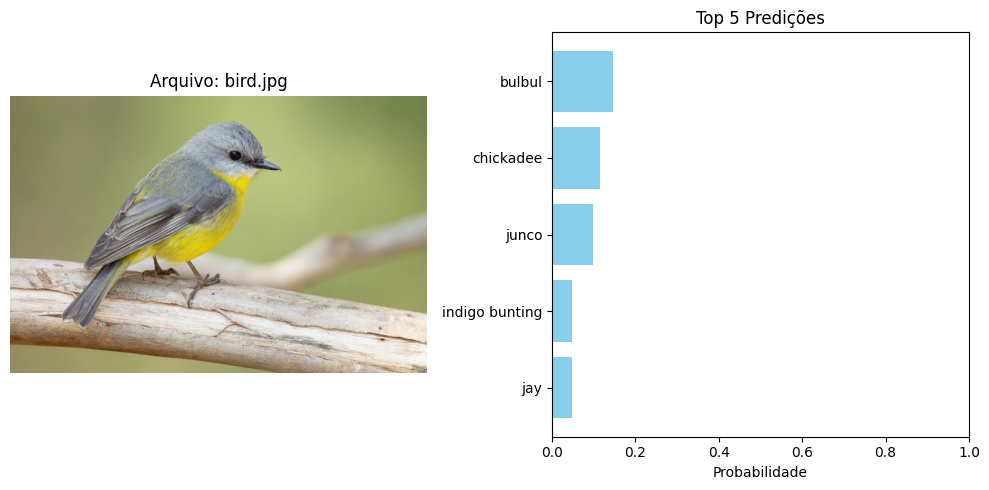

  - bulbul: 14.63%
  - chickadee: 11.52%
  - junco: 9.89%
  - indigo bunting: 4.72%
  - jay: 4.67%

Classificando: cats_dog.png...


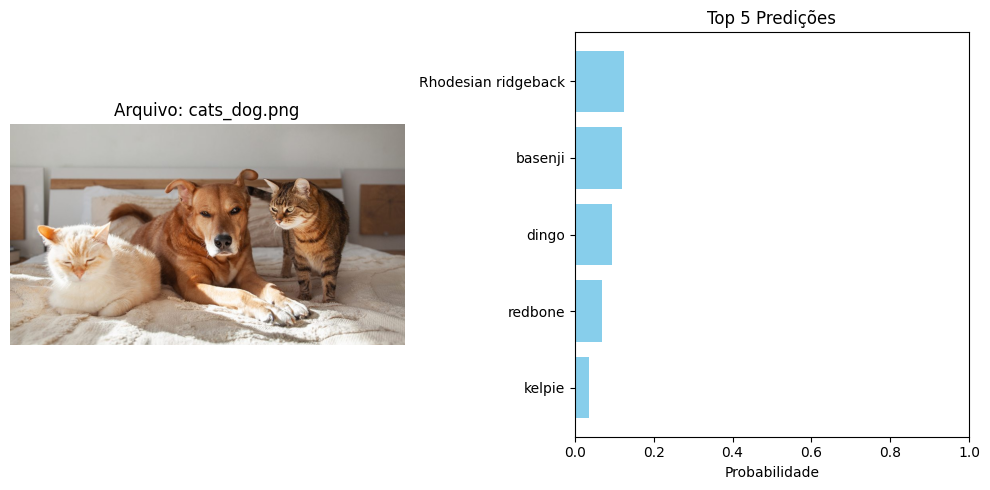

  - Rhodesian ridgeback: 12.38%
  - basenji: 12.06%
  - dingo: 9.30%
  - redbone: 6.86%
  - kelpie: 3.58%

Classificando: kitchen.png...


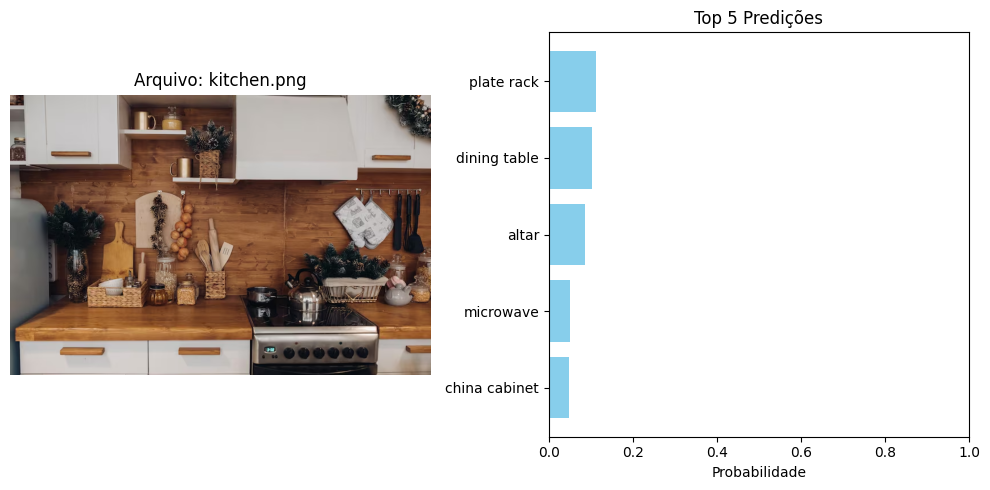

  - plate rack: 11.20%
  - dining table: 10.31%
  - altar: 8.53%
  - microwave: 5.08%
  - china cabinet: 4.85%

Classificando: pizza.png...


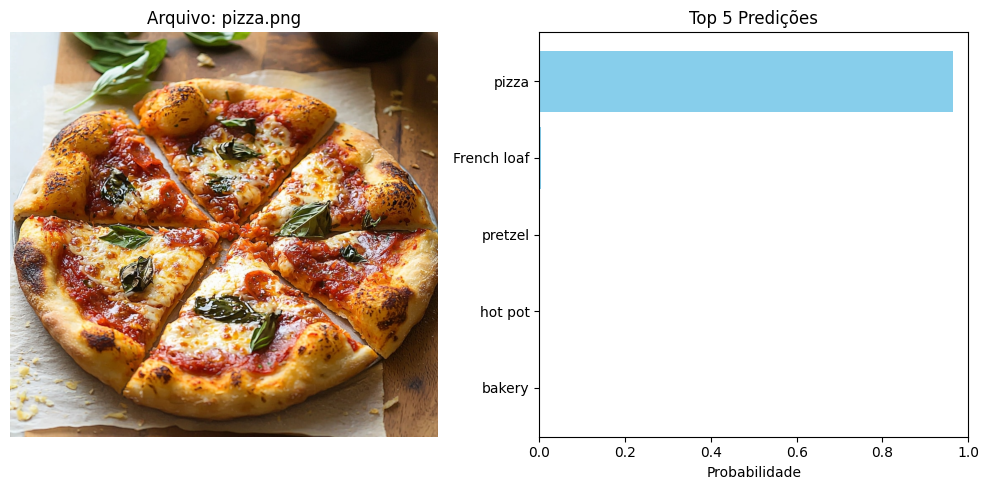

  - pizza: 96.34%
  - French loaf: 0.35%
  - pretzel: 0.22%
  - hot pot: 0.17%
  - bakery: 0.14%


In [8]:
image_folder = 'imagens'
valid_extensions = ('.png', '.jpg', '.jpeg', '.webp')
image_files = [f for f in os.listdir(image_folder) if f.lower().endswith(valid_extensions)]

if not image_files:
    print(f"Nenhuma imagem encontrada na pasta '{image_folder}'.")
else:
    for image_file in image_files:
        img_path = os.path.join(image_folder, image_file)
        print(f"\nClassificando: {image_file}...")
        
        results = classify_image(img_path)
        
        # Exibição básica
        plt.figure(figsize=(10, 5))
        
        # Mostrar a imagem
        plt.subplot(1, 2, 1)
        plt.imshow(Image.open(img_path))
        plt.title(f"Arquivo: {image_file}")
        plt.axis('off')
        
        # Mostrar as predições num gráfico de barras
        plt.subplot(1, 2, 2)
        labels = [r[0] for r in results][::-1] # Inverter para o gráfico ficar bonito
        probs = [r[1] for r in results][::-1]
        
        plt.barh(labels, probs, color='skyblue')
        plt.xlabel('Probabilidade')
        plt.title('Top 5 Predições')
        plt.xlim(0, 1) # Probabilidade de 0 a 1
        
        plt.tight_layout()
        plt.show()
        
        for cat, prob in results:
            print(f"  - {cat}: {prob*100:.2f}%")